In [ ]:
# memory
# sharing parameter--> across timestep-->why?-->
# sequential data handling

In [ ]:
#T1(h1)(x1)--W-->T2(h2)(x2)--W-->T3(h3)(x3)-->--W--->T30(h30)(x30)-->y=(31st day closing price)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Using device: cuda


In [ ]:
def load_prices():
    '''Try real data via yfinance; fall back to synthetic on any failure.'''
    try:
        import yfinance as yf
        raw = yf.download("RELIANCE.NS", start="2015-01-01", end="2026-01-01",
                          interval='1d', auto_adjust=True, progress=False)
        if raw is None or len(raw) == 0:
            raise RuntimeError("empty download")

        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        raw = raw[["Open", "High", "Low", "Close", "Volume"]].dropna()
        print(f"Loaded REAL data for RELIANCE.NS: {len(raw)} rows "
              f"({raw.index.min().date()} -> {raw.index.max().date()}).")
        return raw
    except Exception as e:
        print("yfinance unavailable (", repr(e), ") -> using synthetic fallback.")
        return None


data_raw = load_prices()
data_raw.head()

Loaded REAL data for RELIANCE.NS: 2716 rows (2015-01-01 -> 2025-12-31).


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-01,188.784556,189.998667,188.220086,189.125351,2963643
2015-01-02,189.167989,190.861371,188.358586,188.624832,7331366
2015-01-05,188.507695,189.764420,186.185957,186.558716,10103941
2015-01-06,185.312621,185.951626,177.218496,178.091812,18627980
2015-01-07,178.304843,182.927005,178.283544,181.968491,20720312


In [ ]:
LOOKBACK = 30
HORIZON = 1


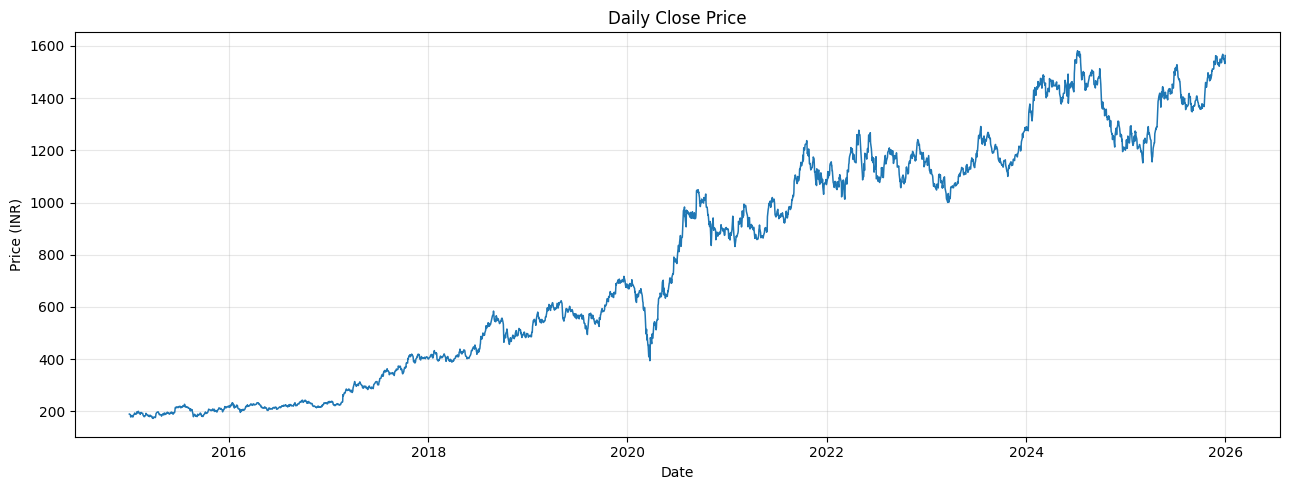

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(data_raw.index, data_raw["Close"], lw=1.1)
ax.set_title("Daily Close Price")
ax.set_xlabel("Date"); ax.set_ylabel("Price (INR)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
FEATURES = ['Open', 'High', 'Low']
TARGET = 'Close'


In [ ]:
def make_windows(feature_matrix,target_vector, lookback):
  X,y = [], []
  for i in range(lookback,len(feature_matrix)):
    X.append(feature_matrix[i-lookback:i])
    y.append(target_vector[i])
  return np.array(X, dtype = np.float32),np.array(y, dtype = np.float32)

In [ ]:
feature_matrix = data_raw[FEATURES].values.astype(np.float32)
target_vector = data_raw[TARGET].values.astype(np.float32).reshape(-1,1)

In [ ]:
feature_matrix.shape

(2716, 3)

In [ ]:
target_vector.shape

(2716, 1)

In [ ]:
X_all, y_all = make_windows(feature_matrix,target_vector,LOOKBACK)
print("X_all shape: ",X_all.shape)
print("y_all shape:", y_all.shape)

X_all shape:  (2686, 30, 3)
y_all shape: (2686, 1)


In [ ]:
n = len(X_all)
i_train = int(n*0.80) # 2000
i_val = int(n*(0.80+0.1)) # 2200
X_train,y_train = X_all[:i_train], y_all[:i_train]
X_val,y_val = X_all[i_train:i_val], y_all[i_train:i_val]
X_test, y_test = X_all[i_val:], y_all[i_val:]


In [ ]:
X_train.shape, X_val.shape, X_test.shape

((2148, 30, 3), (269, 30, 3), (269, 30, 3))

In [ ]:
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()


def scale_X(X, scaler, fit=False):
    flat = X.reshape(-1, X.shape[-1])
    flat = scaler.fit_transform(flat) if fit else scaler.transform(flat)
    return flat.reshape(X.shape).astype(np.float32)

X_train = scale_X(X_train, feat_scaler, fit=True)     # FIT here (train only)
X_val   = scale_X(X_val,   feat_scaler)               # transform only
X_test  = scale_X(X_test,  feat_scaler)               # transform only

y_train = target_scaler.fit_transform(y_train).astype(np.float32)  # FIT on train targets
y_val   = target_scaler.transform(y_val).astype(np.float32)
y_test  = target_scaler.transform(y_test).astype(np.float32)

print("After scaling -> train feature mean ~%.2f, std ~%.2f"
      % (X_train.mean(), X_train.std()))

After scaling -> train feature mean ~-0.00, std ~1.00


In [ ]:
from torch.utils.data import Dataset, DataLoader

In [ ]:
Xtr_t, ytr_t = torch.from_numpy(X_train), torch.from_numpy(y_train)
Xva_t, yva_t = torch.from_numpy(X_val),   torch.from_numpy(y_val)
Xte_t, yte_t = torch.from_numpy(X_test),  torch.from_numpy(y_test)

In [ ]:
class SeqDataset(Dataset):
  def __init__(self,X,y):
    self.X, self.y = X,y
  def __len__(self):
    return len(self.X)
  def __getitem__(self,i):
    return self.X[i], self.y[i]

In [ ]:
BATCH_SIZE = 32

In [ ]:
train_loader = DataLoader(SeqDataset(Xtr_t,ytr_t), batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(SeqDataset(Xva_t,yva_t), batch_size = BATCH_SIZE, shuffle = False)
test_loader = DataLoader(SeqDataset(Xva_t,yva_t), batch_size = BATCH_SIZE, shuffle = False)


In [ ]:
xb, yb = next(iter(train_loader))
print(xb.shape)
print(yb.shape)

torch.Size([32, 30, 3])
torch.Size([32, 1])


In [ ]:
class RNNForecaster(nn.Module):
  def __init__(self,n_features,hidden_size,num_layers = 1):
    super().__init__()
    self.hidden_size = 64
    self.num_layers = num_layers
    # nonlinearity = tanh
    # with relu, you can have problem of exploding
    self.rnn = nn.RNN(input_size = n_features, hidden_size = hidden_size, num_layers = num_layers, batch_first = True, nonlinearity='tanh')
    self.head = nn.Linear(hidden_size, 1)

  def forward(self,x):
    b = x.size(0)
    h0 = torch.zeros(self.num_layers, b, self.hidden_size, device = x.device)# [numL, B, H]
    out, h_n = self.rnn(x,h0) # out: [B,T,H]
    last = out[:,-1,:]
    return self.head(last)


In [ ]:
rnn_model = RNNForecaster(3,64,1)
print(rnn_model)

RNNForecaster(
  (rnn): RNN(3, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
print(sum(p.numel() for p in rnn_model.parameters()))

4481


In [ ]:
# h1 = tanh(Wxh.x1 + Whh.h0 + b)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
NUM_EPOCHS = 40
CLIP_NORM = 1
rnn_model.to(device)
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

def evaluate(X_t, y_scaled):
    """Return (RMSE in INR, R^2) for a dataset."""
    rnn_model.eval()
    with torch.no_grad():
        pred = rnn_model(X_t.to(device)).cpu().numpy()
    y_true = target_scaler.inverse_transform(y_scaled)   # scaled -> INR
    y_pred = target_scaler.inverse_transform(pred)
    return np.sqrt(mean_squared_error(y_true, y_pred)), r2_score(y_true, y_pred)

for epoch in range(NUM_EPOCHS):
    rnn_model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(rnn_model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), CLIP_NORM)
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_loader.dataset)

    train_rmse, train_r2 = evaluate(Xtr_t, y_train)
    val_rmse,   val_r2   = evaluate(Xva_t, y_val)
    print(f"epoch {epoch+1:2d}/{NUM_EPOCHS} | loss {train_loss:.4f} "
          f"| train RMSE {train_rmse:6.2f} R2 {train_r2:5.3f} "
          f"| val RMSE {val_rmse:6.2f} R2 {val_r2:5.3f}")

epoch  1/40 | loss 0.0956 | train RMSE  23.15 R2 0.996 | val RMSE 118.99 R2 -0.147
epoch  2/40 | loss 0.0034 | train RMSE  19.29 R2 0.997 | val RMSE  86.53 R2 0.394
epoch  3/40 | loss 0.0028 | train RMSE  19.10 R2 0.997 | val RMSE  80.09 R2 0.480
epoch  4/40 | loss 0.0026 | train RMSE  19.20 R2 0.997 | val RMSE  72.45 R2 0.575
epoch  5/40 | loss 0.0027 | train RMSE  17.62 R2 0.998 | val RMSE  63.96 R2 0.669
epoch  6/40 | loss 0.0024 | train RMSE  16.80 R2 0.998 | val RMSE  53.10 R2 0.772
epoch  7/40 | loss 0.0023 | train RMSE  17.53 R2 0.998 | val RMSE  47.27 R2 0.819
epoch  8/40 | loss 0.0022 | train RMSE  16.95 R2 0.998 | val RMSE  46.26 R2 0.827
epoch  9/40 | loss 0.0022 | train RMSE  16.92 R2 0.998 | val RMSE  59.45 R2 0.714
epoch 10/40 | loss 0.0021 | train RMSE  16.07 R2 0.998 | val RMSE  51.34 R2 0.787
epoch 11/40 | loss 0.0023 | train RMSE  15.85 R2 0.998 | val RMSE  53.04 R2 0.772
epoch 12/40 | loss 0.0020 | train RMSE  16.95 R2 0.998 | val RMSE  56.20 R2 0.744
epoch 13/40 | l

In [ ]:
rnn_model.eval()
with torch.no_grad():
    test_pred_scaled = rnn_model(Xte_t.to(device)).cpu().numpy()

y_test_true = target_scaler.inverse_transform(y_test)          # actual price (INR)
y_test_pred = target_scaler.inverse_transform(test_pred_scaled)  # predicted price (INR)

test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_r2   = r2_score(y_test_true, y_test_pred)
print(f"Test RMSE: {test_rmse:.2f} INR | Test R2: {test_r2:.3f}")

Test RMSE: 33.89 INR | Test R2: 0.909


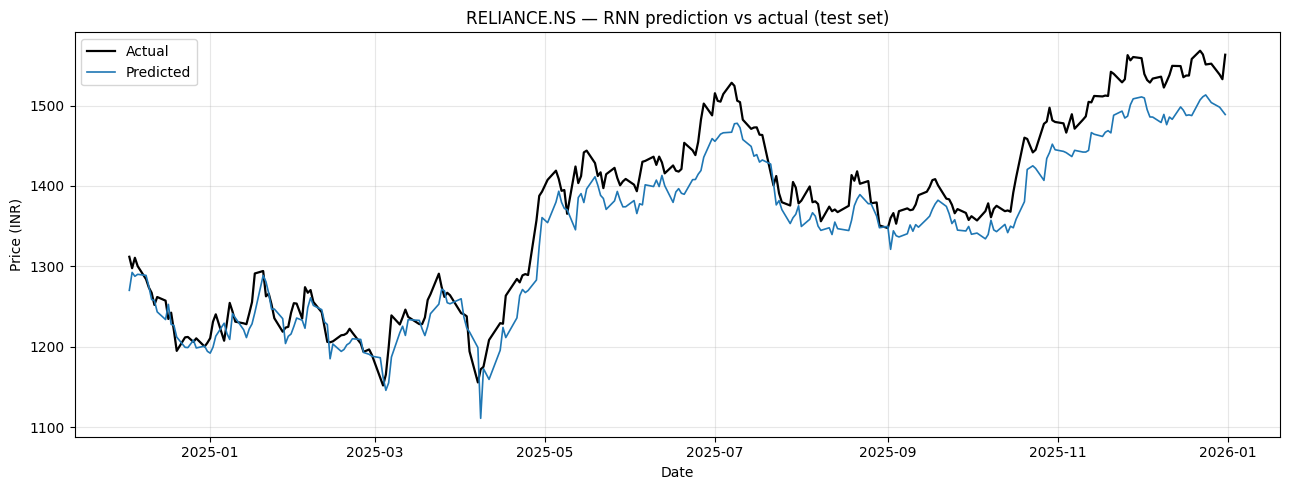

In [ ]:
# each test target is the day AFTER its window, so align dates from LOOKBACK onward
test_dates = data_raw.index[LOOKBACK:][-len(y_test_true):]

plt.figure(figsize=(13, 5))
plt.plot(test_dates, y_test_true, label="Actual",    color="black", lw=1.6)
plt.plot(test_dates, y_test_pred, label="Predicted", lw=1.2)
plt.title("RELIANCE.NS — RNN prediction vs actual (test set)")
plt.xlabel("Date"); plt.ylabel("Price (INR)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()